In [ ]:
import numpy as np
import gif
import iw
from tqdm.notebook import tqdm
import pandas as pd

In [2]:
sessions, conversions, conversion_rates = iw.generate_dataset(
    num_users=10000,
    sessions_skew=2.5,
    #cvr_func=lambda x,y: x*(1/10 + 9/10*np.exp(-0.05*(y-1))),
    cvr_decay_factor=0.1,
    beta_size=100,
    baseline_conversion_rate=0.2    
)

sessions_ctrl, sessions_test, conversions_ctrl, conversions_test = iw.generate_experiment_datasets(
    sessions, 
    conversions, 
    num_experiments=10000
)

In [3]:
# run all tests
bootstrapped_null_dist = iw.get_bootstrapped_null_hypothesis_distribution(
    sessions=np.append(sessions_ctrl[0], sessions_test[0]),
    conversions=np.append(conversions_ctrl[0], conversions_test[0]), 
    num_bootstraps=10000
)

bs_p_values = iw.bootstrapped_p_values(
    sessions_ctrl, conversions_ctrl, sessions_test, conversions_test, bootstrapped_null_dist
)

binom_p_values = iw.binomial_z_test(sessions_ctrl, conversions_ctrl, sessions_test, conversions_test)
delta_p_values = iw.delta_method_z_test(sessions_ctrl, conversions_ctrl, sessions_test, conversions_test)

In [4]:
(bs_p_values <= 0.05).mean()

np.float64(0.0445)

In [5]:
(delta_p_values <= 0.05).mean()

np.float64(0.0583)

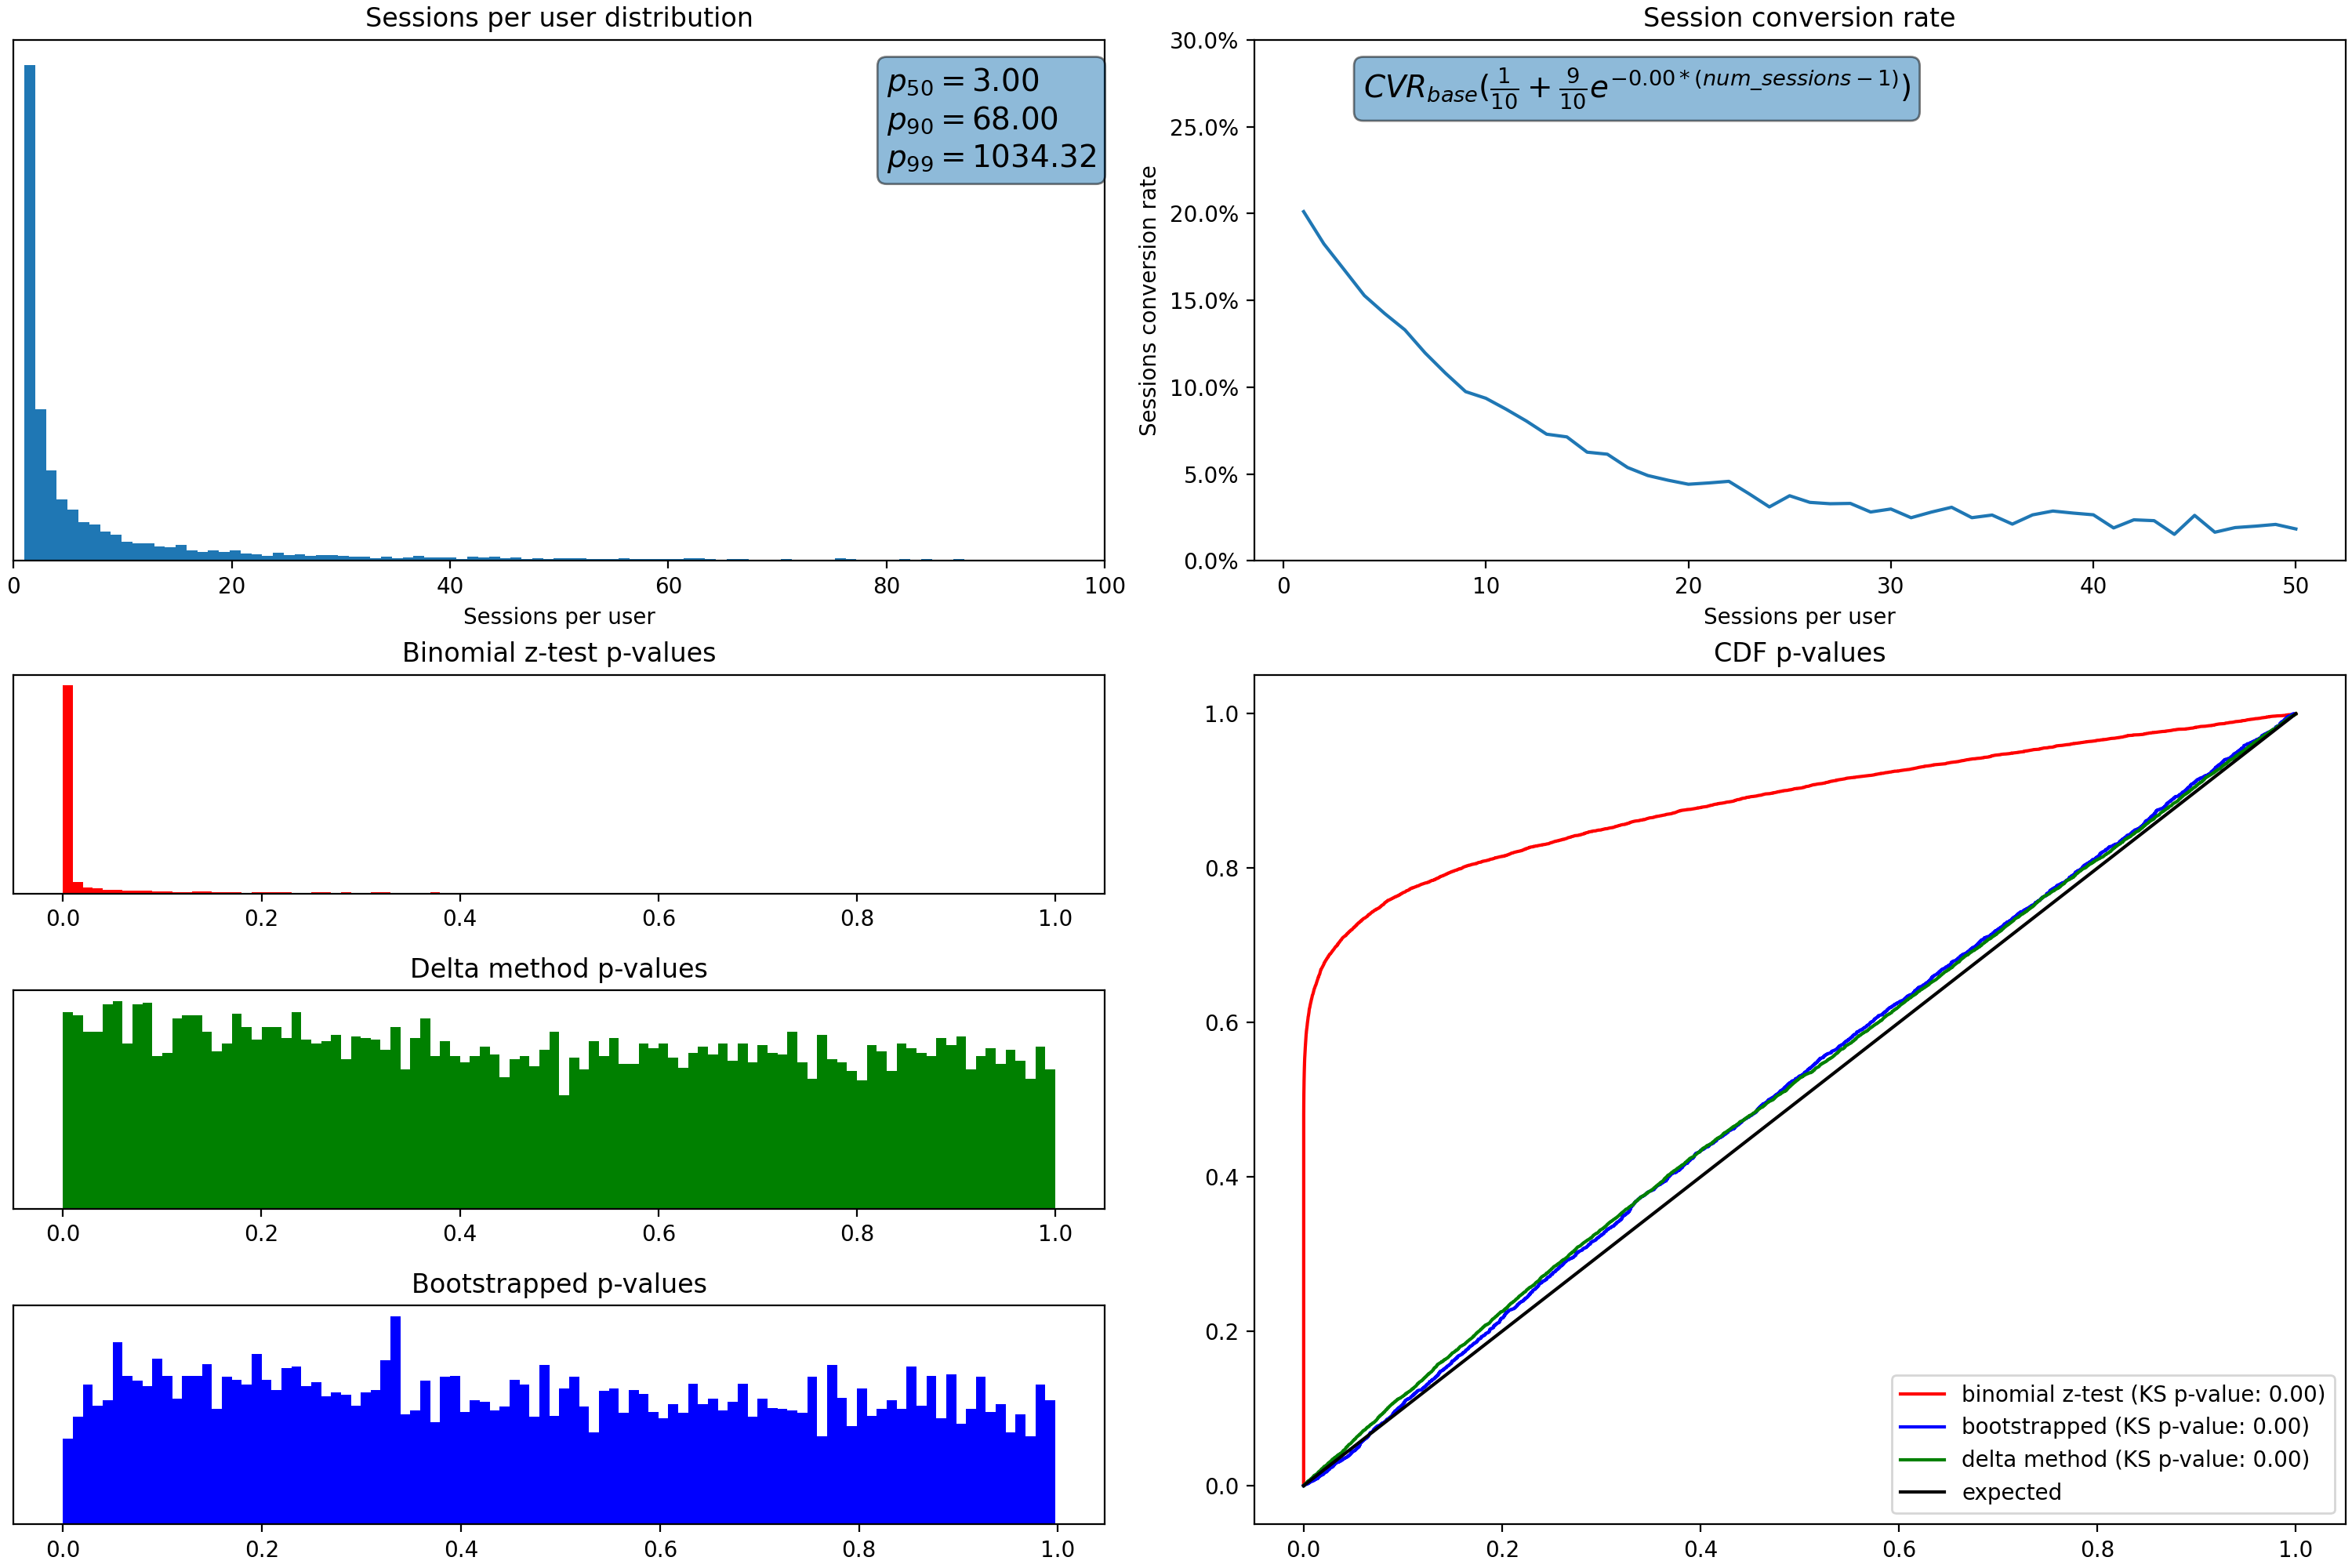

In [6]:
frame = iw.plot(sessions, conversion_rates, binom_p_values, delta_p_values, bs_p_values, 0, plot_all=True);
frame

In [7]:
frames = []
frames_all = []

sessions_skew=2.5
num_users = 10_000
num_experiments = 10_000
baseline_conversion_rate = 0.2
cvr_decay_factor = 0.1
beta_size = 100
results = []

for cvr_decay_factor in tqdm(np.linspace(0.0, 0.1, 10)):    
    sessions, conversions, conversion_rates = iw.generate_dataset(
        num_users=num_users,
        baseline_conversion_rate=baseline_conversion_rate,
        sessions_skew=sessions_skew,
        cvr_decay_factor=cvr_decay_factor,
        beta_size=beta_size
    )

    sessions_ctrl, sessions_test, conversions_ctrl, conversions_test = iw.generate_experiment_datasets(
        sessions, 
        conversions, 
        num_experiments=num_experiments
    )

    #run all tests
    bootstrapped_null_dist = iw.get_bootstrapped_null_hypothesis_distribution(
        sessions=np.append(sessions_ctrl[0], sessions_test[0]),
        conversions=np.append(conversions_ctrl[0], conversions_test[0]), 
        num_bootstraps=10000
    )

    bs_p_values = iw.bootstrapped_p_values(
        sessions_ctrl, conversions_ctrl, sessions_test, conversions_test, bootstrapped_null_dist
    )

    binom_p_values = iw.binomial_z_test(sessions_ctrl, conversions_ctrl, sessions_test, conversions_test)
    delta_p_values = iw.delta_method_z_test(sessions_ctrl, conversions_ctrl, sessions_test, conversions_test)

    results.append({
        'cvr_decay_factor': cvr_decay_factor,
        'binom_p_values': np.mean(binom_p_values <= 0.05),
        'delta_p_values': np.mean(delta_p_values <= 0.05),
        'bs_p_values': np.mean(bs_p_values <= 0.05),
        'sessions_skew': sessions_skew,        
    })

    frame = iw.plot(sessions, conversion_rates, binom_p_values, delta_p_values, bs_p_values, cvr_decay_factor, plot_all=False)
    frames.append(frame)
    
    frame = iw.plot(sessions, conversion_rates, binom_p_values, delta_p_values, bs_p_values, cvr_decay_factor, plot_all=True)
    frames_all.append(frame)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [01:21<00:00,  8.16s/it]


In [8]:
gif.save(frames, "p_values_cvr_decay_factor.gif", duration=1000)
gif.save(frames_all, "p_values_cvr_decay_factor_all.gif", duration=1000)

In [13]:
pd.DataFrame(results)

,cvr_decay_factor,binom_p_values,delta_p_values,bs_p_values,sessions_skew
0,0.000000,0.7766,0.1472,0.0520,2.5
1,0.011111,0.8471,0.0662,0.0433,2.5
2,0.022222,0.7899,0.0644,0.0585,2.5
3,0.033333,0.7514,0.0624,0.0499,2.5
4,0.044444,0.7829,0.0701,0.0528,2.5
5,0.055556,0.8270,0.0844,0.0592,2.5
6,0.066667,0.6742,0.0634,0.0452,2.5
7,0.077778,0.9937,0.2230,0.0427,2.5
8,0.088889,0.9872,0.2109,0.0429,2.5
9,0.100000,0.7404,0.0677,0.0405,2.5
